<a href="https://colab.research.google.com/github/Vikverm/Global-Corona-Pandemic-Analysis/blob/main/Global_Corona_Pandemic_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()


In [ ]:
pip install pandas matplotlib seaborn plotly



Loading Dataset...

Dataset Preview:
      location iso_code        date  total_vaccinations  people_vaccinated  \
0  Afghanistan      AFG  2021-02-22                 0.0                0.0   
1  Afghanistan      AFG  2021-02-23                 NaN                NaN   
2  Afghanistan      AFG  2021-02-24                 NaN                NaN   
3  Afghanistan      AFG  2021-02-25                 NaN                NaN   
4  Afghanistan      AFG  2021-02-26                 NaN                NaN   

   people_fully_vaccinated  total_boosters  daily_vaccinations_raw  \
0                      NaN             NaN                     NaN   
1                      NaN             NaN                     NaN   
2                      NaN             NaN                     NaN   
3                      NaN             NaN                     NaN   
4                      NaN             NaN                     NaN   

   daily_vaccinations  total_vaccinations_per_hundred  \
0              

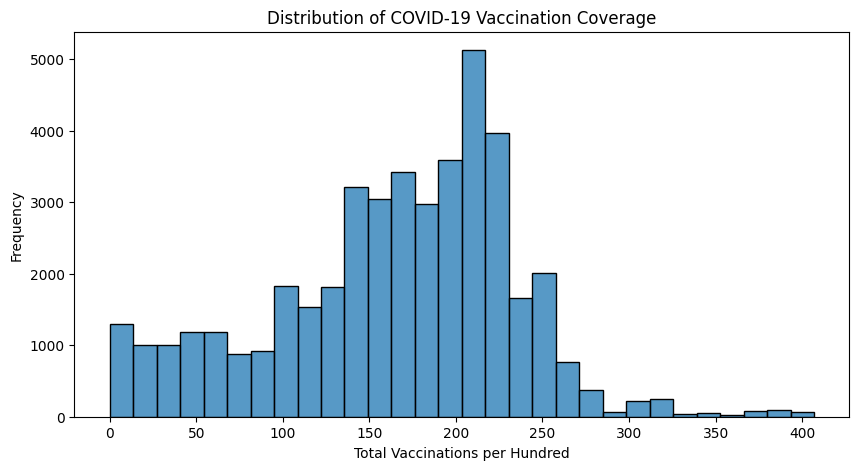


Displaying World Map Visualization...



---------------- INTERPRETATION OF RESULTS ----------------

1. Countries with higher vaccination per hundred indicate stronger
   vaccination campaigns and better healthcare infrastructure.

2. The distribution graph shows unequal vaccination coverage across
   countries, meaning vaccine availability and access varied globally.

3. Developed nations generally appear among the highest vaccinated
   countries, while several developing countries show lower coverage.

4. Some countries are excluded from analysis because vaccination
   data was missing or not disclosed in the dataset.

5. The world map visualization highlights global differences in
   vaccination coverage and shows how vaccination progress varied
   across regions during the pandemic.


Mini Project Execution Completed Successfully.


In [ ]:
# ============================================================
# MINI PROJECT
# Global COVID-19 Vaccination Analysis
# Dataset Source: Our World in Data
# ============================================================

# ---------------------------
# Import Required Libraries
# ---------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ---------------------------
# 1. Load Dataset
# ---------------------------
print("\nLoading Dataset...\n")

df = pd.read_csv("covid-vaccination-doses-per-capita.csv")

print("Dataset Preview:")
print(df.head())

print("\nDataset Information:")
print(df.info())


# ---------------------------
# 2. Data Cleaning
# ---------------------------
print("\nCleaning Dataset...")

# Removing rows with missing values
df = df.dropna()

print("Missing values removed successfully.")


# ---------------------------
# 3. Latest Vaccination Data
# ---------------------------
print("\nFinding Latest Vaccination Data by Country...")

# Get latest record for each country
latest_data = df.sort_values('date').groupby('location').last()

# Top 10 vaccinated countries
top10 = latest_data.sort_values(
    'total_vaccinations_per_hundred',
    ascending=False
).head(10)

print("\nTop 10 Countries by Vaccination per Hundred:")
print(top10[['total_vaccinations_per_hundred']])


# ---------------------------
# 4. Statistical Analysis
# ---------------------------
print("\nStatistical Summary of Vaccination Data:")
print(df['total_vaccinations_per_hundred'].describe())


# ---------------------------
# 5. Distribution Graph
# ---------------------------
print("\nDisplaying Vaccination Distribution Graph...")

plt.figure(figsize=(10,5))
sns.histplot(df['total_vaccinations_per_hundred'], bins=30)
plt.title("Distribution of COVID-19 Vaccination Coverage")
plt.xlabel("Total Vaccinations per Hundred")
plt.ylabel("Frequency")
plt.show()


# ---------------------------
# 6. World Map Visualization
# ---------------------------
print("\nDisplaying World Map Visualization...")

fig = px.choropleth(
    latest_data,
    locations="iso_code",
    color="total_vaccinations_per_hundred",
    hover_name=latest_data.index,
    color_continuous_scale="Viridis",
    title="Global COVID Vaccination Coverage"
)

fig.show()


# ---------------------------
# 7. Interpretation of Results
# ---------------------------
print("\n---------------- INTERPRETATION OF RESULTS ----------------")

print("""
1. Countries with higher vaccination per hundred indicate stronger
   vaccination campaigns and better healthcare infrastructure.

2. The distribution graph shows unequal vaccination coverage across
   countries, meaning vaccine availability and access varied globally.

3. Developed nations generally appear among the highest vaccinated
   countries, while several developing countries show lower coverage.

4. Some countries are excluded from analysis because vaccination
   data was missing or not disclosed in the dataset.

5. The world map visualization highlights global differences in
   vaccination coverage and shows how vaccination progress varied
   across regions during the pandemic.
""")

print("\nMini Project Execution Completed Successfully.")
